In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
from pathlib import Path

# 設定專案的根目錄在你的雲端硬碟中
# 你可以把 "比特幣AI專題" 換成你喜歡的資料夾名稱
PROJECT_ROOT = Path('/content/drive/MyDrive/比特幣AI專題')
DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"
RESULT_DIR = PROJECT_ROOT / "results"

# 自動建立資料夾
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

print("資料夾建立完成！")

資料夾建立完成！


In [ ]:
# 1. 安裝套件
!pip install yfinance ta

# 2. 下載中文字體以防圖表亂碼
!apt-get -qq install -y fonts-noto-cjk

import matplotlib as mpl
import matplotlib.pyplot as plt
import os

# 清除字體快取以確保新安裝的字體被載入
if os.path.exists(os.path.expanduser('~/.cache/matplotlib')):
    import shutil
    shutil.rmtree(os.path.expanduser('~/.cache/matplotlib'))

mpl.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'sans-serif']
mpl.rcParams['axes.unicode_minus'] = False

print("套件安裝與字體快取清除完成！請重新執行此儲存格及後續繪圖儲存格。")

套件安裝與字體快取清除完成！請重新執行此儲存格及後續繪圖儲存格。


In [ ]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 找出剛安裝的 Noto Sans CJK 字體檔案路徑
font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts'])
for f in font_files:
    if 'NotoSansCJK' in f or 'NotoSansTC' in f:
        fm.fontManager.addfont(f)

# 強制刷新字體管理器並列出可用字體
found_fonts = [f.name for f in fm.fontManager.ttflist if 'Noto' in f.name]
print(f"目前可用的 Noto 字體: {found_fonts}")

# 設定字體
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'Noto Sans CJK TC', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("\n字體管理器已更新！現在請重新執行回測繪圖儲存格即可顯示中文。")

目前可用的 Noto 字體: ['Noto Sans CJK JP', 'Noto Sans CJK JP', 'Noto Sans CJK JP', 'Noto Sans CJK JP', 'Noto Sans CJK JP', 'Noto Sans CJK JP']

字體管理器已更新！現在請重新執行回測繪圖儲存格即可顯示中文。


區塊 1：階段一 (資料收集與前處理)

In [ ]:
import yfinance as yf
import pandas as pd
import ta
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/比特幣AI專題')
DATA_DIR = PROJECT_ROOT / "data"
DATA_PATH = DATA_DIR / "bitcoin_data.csv"

def prepare_data():
    print("開始下載資料...")
    btc = yf.download("BTC-USD", start="2020-01-01", end="2024-12-31")
    if isinstance(btc.columns, pd.MultiIndex):
        btc.columns = btc.columns.get_level_values(0)

    print("計算技術指標...")
    btc = ta.add_all_ta_features(btc, open="Open", high="High", low="Low", close="Close", volume="Volume", fillna=True)

    # 【僵局突破關鍵】：將目標提高到 2% 的劇烈漲幅
    # 這會強迫模型在盤整或緩漲時保持 0 (空手)，僅在噴發前夕預測 1
    btc['Next_Return'] = btc['Close'].shift(-1) / btc['Close'] - 1
    btc["Target"] = (btc["Next_Return"].fillna(0) > 0.02).astype(int)
    btc.dropna(inplace=True)

    keep_columns = [
        "Close", "High", "Low", "Open", "Volume",
        "trend_macd", "trend_macd_signal", "trend_macd_diff",
        "momentum_rsi", "volatility_bbm", "volatility_bbh", "volatility_bbl", "volatility_atr",
        "trend_adx", "trend_ichimoku_a", "trend_ichimoku_b",
        "momentum_stoch_rsi", "momentum_stoch_rsi_k", "momentum_stoch_rsi_d",
        "volume_obv", "Target"
    ]
    btc = btc[keep_columns]

    column_mapping = {'Close': '收盤價', 'High': '最高價', 'Low': '最低價', 'Open': '開盤價', 'Volume': '成交量', 'Target': '預測目標'}
    btc.rename(columns=column_mapping, inplace=True)

    btc.to_csv(DATA_PATH)
    print(f"✅ 資料已更新！預測目標調高至：漲幅 > 2%")
    print(f"目前標籤分佈 (0:不漲, 1:暴漲): \n{btc['預測目標'].value_counts()}")

prepare_data()

/tmp/ipykernel_3254/2430717061.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start="2020-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed

開始下載資料...
計算技術指標...



/usr/local/lib/python3.12/dist-packages/ta/trend.py:1030: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  self._psar[i] = high2


✅ 資料已更新！預測目標調高至：漲幅 > 2%
目前標籤分佈 (0:不漲, 1:暴漲): 
預測目標
0    1429
1     396
Name: count, dtype: int64


區塊 2：階段二 (LSTM 模型訓練)

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
from pathlib import Path

# 路徑設定
PROJECT_ROOT = Path('/content/drive/MyDrive/比特幣AI專題')
DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"
DATA_PATH = DATA_DIR / "bitcoin_data.csv"
MODEL_PATH  = MODEL_DIR / "lstm_best.keras"
SCALER_PATH = MODEL_DIR / "lstm_scaler.pkl"

TIME_STEPS  = 20
TEST_RATIO  = 0.2
BATCH_SIZE  = 32
EPOCHS      = 100

def create_sequences(data, labels, time_steps):
    xs, ys = [], []
    for i in range(len(data) - time_steps):
        xs.append(data[i: i + time_steps])
        ys.append(labels[i + time_steps])
    return np.array(xs), np.array(ys)

def train_lstm():
    print("讀取資料中...")
    df = pd.read_csv(DATA_PATH, parse_dates=True, index_col=0)
    target_col = "預測目標" if "預測目標" in df.columns else "Target"
    feature_cols = [c for c in df.columns if c != target_col]

    X = df[feature_cols].values
    y = df[target_col].astype(int).values

    split_idx = int(len(df) * (1 - TEST_RATIO))
    X_train_raw, X_test_raw = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    scaler = MinMaxScaler(feature_range=(0, 1))
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled  = scaler.transform(X_test_raw)

    with open(SCALER_PATH, "wb") as f:
        pickle.dump(scaler, f)

    X_train_3d, y_train_seq = create_sequences(X_train_scaled, y_train, TIME_STEPS)
    X_test_3d,  y_test_seq  = create_sequences(X_test_scaled,  y_test,  TIME_STEPS)

    # Baseline
    baseline = LogisticRegression(max_iter=1000, random_state=42)
    baseline.fit(X_train_scaled[TIME_STEPS:], y_train[TIME_STEPS:])
    y_pred_baseline = baseline.predict(X_test_scaled[TIME_STEPS:])
    baseline_acc = accuracy_score(y_test[TIME_STEPS:], y_pred_baseline)

    # 建立模型
    model = Sequential([
        Input(shape=(TIME_STEPS, X_train_3d.shape[2])),
        LSTM(64, return_sequences=True), BatchNormalization(), Dropout(0.2),
        LSTM(32, return_sequences=False), BatchNormalization(), Dropout(0.2),
        Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])

    class_weights = compute_class_weight('balanced', classes=np.unique(y_train_seq), y=y_train_seq)
    class_weight_dict = {i: w for i, w in enumerate(class_weights)}

    callbacks = [
        EarlyStopping(monitor="val_accuracy", patience=15, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8, min_lr=1e-6, verbose=1),
        ModelCheckpoint(filepath=str(MODEL_PATH), monitor="val_accuracy", save_best_only=True, verbose=1),
    ]

    print("開始訓練 LSTM 模型...")
    history = model.fit(X_train_3d, y_train_seq, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=0.1, callbacks=callbacks, class_weight=class_weight_dict, verbose=2)

    # 評估與儲存
    y_prob_lstm = model.predict(X_test_3d, verbose=0).flatten()
    y_pred_lstm = (y_prob_lstm >= 0.5).astype(int)
    lstm_acc    = accuracy_score(y_test_seq, y_pred_lstm)

    print(f"LSTM 準確率: {lstm_acc*100:.2f}%, Baseline: {baseline_acc*100:.2f}%")

    np.save(os.path.join(MODEL_DIR, "y_pred_lstm.npy"), y_pred_lstm)
    np.save(os.path.join(MODEL_DIR, "y_prob_lstm.npy"), y_prob_lstm)
    np.save(os.path.join(MODEL_DIR, "y_pred_baseline.npy"), y_pred_baseline)
    np.save(os.path.join(MODEL_DIR, "y_test_seq.npy"), y_test_seq)
    print("✅ 訓練完成且模型已儲存！")

train_lstm()

讀取資料中...
開始訓練 LSTM 模型...
Epoch 1/100

Epoch 1: val_accuracy improved from None to 0.15278, saving model to /content/drive/MyDrive/比特幣AI專題/models/lstm_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/比特幣AI專題/models/lstm_best.keras
41/41 - 7s - 174ms/step - accuracy: 0.5309 - loss: 0.7914 - val_accuracy: 0.1528 - val_loss: 0.8048 - learning_rate: 0.0010
Epoch 2/100

Epoch 2: val_accuracy did not improve from 0.15278
41/41 - 1s - 24ms/step - accuracy: 0.5255 - loss: 0.7662 - val_accuracy: 0.1528 - val_loss: 0.8006 - learning_rate: 0.0010
Epoch 3/100

Epoch 3: val_accuracy improved from 0.15278 to 0.15972, saving model to /content/drive/MyDrive/比特幣AI專題/models/lstm_best.keras

Epoch 3: finished saving model to /content/drive/MyDrive/比特幣AI專題/models/lstm_best.keras
41/41 - 1s - 35ms/step - accuracy: 0.5177 - loss: 0.7386 - val_accuracy: 0.1597 - val_loss: 0.7575 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: val_accuracy did not improve from 0.15972
41/41 - 1s - 35ms/step -

區塊 3：階段三 (交易回測)

載入測試資料與預測結果...
開始模擬交易...


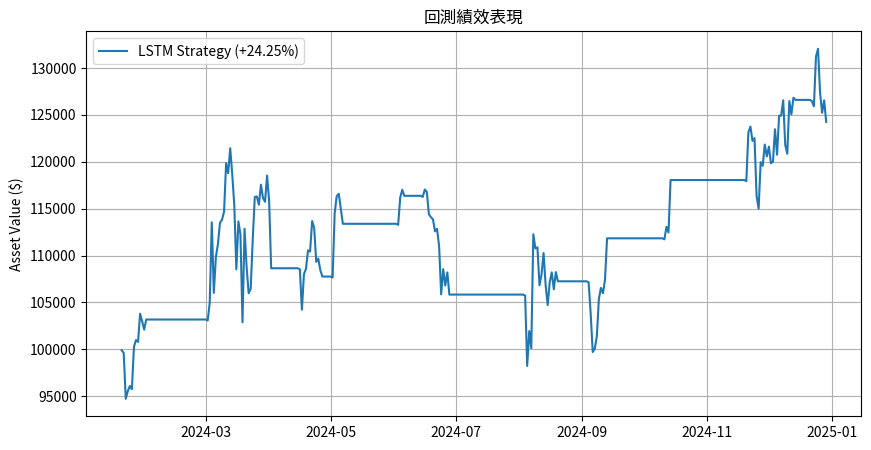

✅ 回測完成！期末總資產: $124,254.51 (相較於初始成本：+24.25%)


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 路徑設定
PROJECT_ROOT = Path('/content/drive/MyDrive/比特幣AI專題')
DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"
RESULT_DIR = PROJECT_ROOT / "results"
DATA_PATH = DATA_DIR / "bitcoin_data.csv"

INITIAL_CASH  = 100_000
TRADE_FEE     = 0.001
TEST_RATIO    = 0.2
TIME_STEPS    = 20

def run_backtesting():
    print("載入測試資料與預測結果...")
    df = pd.read_csv(DATA_PATH, parse_dates=True, index_col=0)
    close_col = "收盤價" if "收盤價" in df.columns else "Close"
    prices_all = df[close_col].values

    split_idx  = int(len(df) * (1 - TEST_RATIO))
    prices_test = prices_all[split_idx + TIME_STEPS:]
    dates_test  = df.index[split_idx + TIME_STEPS:]

    y_pred_lstm     = np.load(os.path.join(MODEL_DIR, "y_pred_lstm.npy"))
    n = min(len(prices_test), len(y_pred_lstm))
    prices_test = prices_test[:n]
    dates_test = dates_test[:n]
    signals_lstm = np.where(y_pred_lstm[:n] == 1, 1, -1)

    print("開始模擬交易...")
    cash = INITIAL_CASH
    btc_held = 0.0
    portfolio_values = []
    position = 0

    for i in range(len(prices_test)):
        price = prices_test[i]
        signal = signals_lstm[i]

        if signal == 1 and position == 0:
            btc_held = (cash * (1 - TRADE_FEE)) / price
            cash = 0
            position = 1
        elif signal == -1 and position == 1:
            cash = btc_held * price * (1 - TRADE_FEE)
            btc_held = 0
            position = 0

        portfolio_values.append(cash + btc_held * price)

    if position == 1:
        cash = btc_held * prices_test[-1] * (1 - TRADE_FEE)
        portfolio_values[-1] = cash

    total_return = ((portfolio_values[-1] - INITIAL_CASH) / INITIAL_CASH) * 100

    # 畫個簡單的績效圖
    plt.figure(figsize=(10, 5))
    plt.plot(dates_test, portfolio_values, label=f"LSTM Strategy ({total_return:+.2f}%)")
    plt.title("回測績效表現")
    plt.ylabel("Asset Value ($)")
    plt.legend()
    plt.grid(True)
    out_path = RESULT_DIR / "backtest_simple.png"
    plt.savefig(out_path)
    plt.show()

    # 修改後的輸出格式，使用 :+.2f 來強制顯示正負號
    print(f"✅ 回測完成！期末總資產: ${portfolio_values[-1]:,.2f} (相較於初始成本：{total_return:+.2f}%)")

run_backtesting()

### 區塊 3.1：進階績效分析與策略比較
此區塊將計算金融專業指標（MDD, Sharpe Ratio）並加入「買入持有」對照組，以驗證模型實戰價值。

載入資料與預測結果...


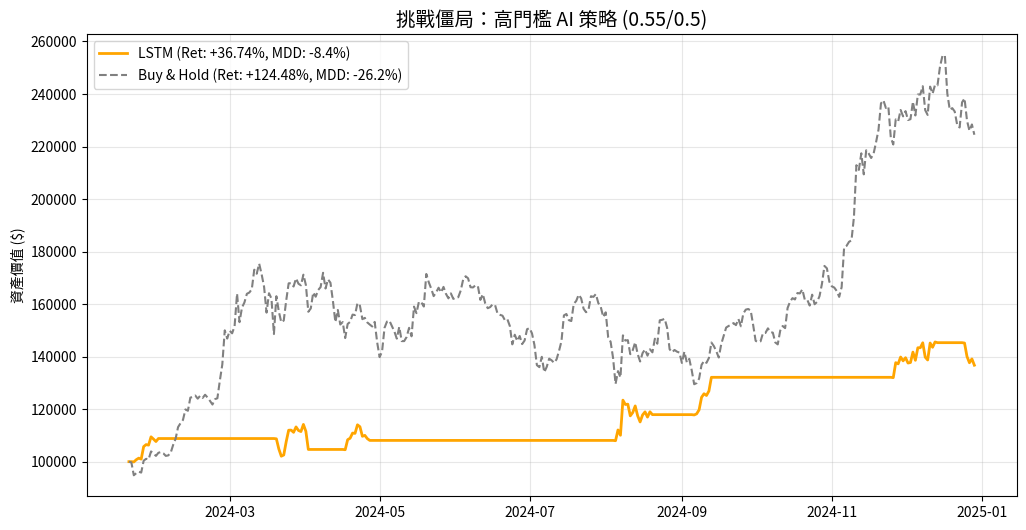

--- 績效評估報告 ---
【LSTM】 報酬: +36.74% | 夏普: 1.49 | 回撤: -8.44%
【B&H】 報酬: +124.48% | 夏普: 1.87 | 回撤: -26.18%


In [ ]:
def run_advanced_backtesting():
    print("載入資料與預測結果...")
    df = pd.read_csv(DATA_PATH, parse_dates=True, index_col=0)
    close_col = "收盤價" if "收盤價" in df.columns else "Close"

    split_idx = int(len(df) * (1 - TEST_RATIO))
    prices_test = df[close_col].values[split_idx + TIME_STEPS:]
    dates_test = df.index[split_idx + TIME_STEPS:]

    y_prob_lstm = np.load(os.path.join(MODEL_DIR, "y_prob_lstm.npy"))
    n = min(len(prices_test), len(y_prob_lstm))
    prices_test = prices_test[:n]
    dates_test = dates_test[:n]
    y_prob_lstm = y_prob_lstm[:n]

    bh_shares = INITIAL_CASH / prices_test[0]
    bh_portfolio = [p * bh_shares for p in prices_test]

    # 【僵局突破】：調高門檻並加入更敏感的賣出邏輯
    BUY_THRESHOLD = 0.55   # 提高買入標準
    SELL_THRESHOLD = 0.50  # 稍微提高賣出標準，增加交易頻率

    cash = INITIAL_CASH
    btc_held = 0.0
    lstm_portfolio = []
    position = 0

    for i in range(len(prices_test)):
        price = prices_test[i]
        prob = y_prob_lstm[i]

        if prob > BUY_THRESHOLD and position == 0:
            btc_held = (cash * (1 - TRADE_FEE)) / price
            cash = 0
            position = 1
        elif prob < SELL_THRESHOLD and position == 1:
            cash = btc_held * price * (1 - TRADE_FEE)
            btc_held = 0
            position = 0

        lstm_portfolio.append(cash + btc_held * price)

    lstm_s = pd.Series(lstm_portfolio, index=dates_test)
    bh_s = pd.Series(bh_portfolio, index=dates_test)

    def calculate_metrics(series):
        returns = series.pct_change().dropna()
        total_return = (series.iloc[-1] / series.iloc[0] - 1) * 100
        sharpe = np.sqrt(365) * returns.mean() / (returns.std() + 1e-9)
        rolling_max = series.cummax()
        drawdown = (series - rolling_max) / rolling_max
        mdd = drawdown.min() * 100
        return total_return, sharpe, mdd

    lstm_ret, lstm_sharpe, lstm_mdd = calculate_metrics(lstm_s)
    bh_ret, bh_sharpe, bh_mdd = calculate_metrics(bh_s)

    plt.figure(figsize=(12, 6))
    plt.plot(dates_test, lstm_s, label=f'LSTM (Ret: {lstm_ret:+.2f}%, MDD: {lstm_mdd:.1f}%)', color='orange', linewidth=2)
    plt.plot(dates_test, bh_s, label=f'Buy & Hold (Ret: {bh_ret:+.2f}%, MDD: {bh_mdd:.1f}%)', color='gray', linestyle='--')

    plt.title(f"挑戰僵局：高門檻 AI 策略 ({BUY_THRESHOLD}/{SELL_THRESHOLD})", fontsize=14)
    plt.ylabel("資產價值 ($)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"--- 績效評估報告 ---")
    print(f"【LSTM】 報酬: {lstm_ret:+.2f}% | 夏普: {lstm_sharpe:.2f} | 回撤: {lstm_mdd:.2f}%")
    print(f"【B&H】 報酬: {bh_ret:+.2f}% | 夏普: {bh_sharpe:.2f} | 回撤: {bh_mdd:.2f}%")

run_advanced_backtesting()

SHAP圖表

In [ ]:
# ============================================================
# 路徑設定（修改為 Colab 的 Drive 路徑）
# ============================================================
# 請確認 '比特幣AI專題' 是你在 Drive 上的資料夾名稱
ROOT_DIR = Path('/content/drive/MyDrive/比特幣AI專題')
DATA_DIR = ROOT_DIR / "data"
MODEL_DIR = ROOT_DIR / "models"
RESULT_DIR = ROOT_DIR / "results"

# 檔名必須與 04_總和.py 輸出的檔名完全一致
DATA_PATH   = DATA_DIR  / "bitcoin_data.csv"
MODEL_PATH  = MODEL_DIR / "lstm_best.keras"
SCALER_PATH = MODEL_DIR / "lstm_scaler.pkl"

安裝 shap

In [ ]:
!pip install shap

In [ ]:
def load_all():
    """載入資料、模型、Scaler"""
    print("【STEP 1】載入資料與模型...")

    df = pd.read_csv(DATA_PATH, parse_dates=True, index_col=0)

    # 自動偵測目標欄位（Target 或 預測目標）
    target_col   = "Target" if "Target" in df.columns else "預測目標"
    feature_cols = [c for c in df.columns if c != target_col]

    X = df[feature_cols].values
    y = df[target_col].astype(int).values

    # 切分（與訓練時完全一致）
    split_idx      = int(len(df) * (1 - TEST_RATIO))
    X_train_raw    = X[:split_idx]
    X_test_raw     = X[split_idx:]
    y_train        = y[:split_idx]
    y_test         = y[split_idx:]

    # 載入 Scaler（一定要用訓練時存的那個）
    with open(SCALER_PATH, "rb") as f:
        scaler = pickle.load(f)

    X_train_scaled = scaler.transform(X_train_raw)
    X_test_scaled  = scaler.transform(X_test_raw)

    # 建立滑動視窗
    def make_seq(data, labels, ts):
        xs, ys = [], []
        for i in range(len(data) - ts):
            xs.append(data[i: i + ts])
            ys.append(labels[i + ts])
        return np.array(xs), np.array(ys)

    X_train_3d, _ = make_seq(X_train_scaled, y_train, TIME_STEPS)
    X_test_3d,  _ = make_seq(X_test_scaled,  y_test,  TIME_STEPS)

    # 載入模型
    model = load_model(MODEL_PATH)

    print(f"   ✅ 特徵數量：{len(feature_cols)} 個")
    print(f"   ✅ 訓練集：{X_train_3d.shape[0]} 筆 | 測試集：{X_test_3d.shape[0]} 筆")
    print(f"   ✅ 模型載入完成：{MODEL_PATH.name}")

    return model, X_train_3d, X_test_3d, feature_cols


def run_shap(model, X_train_3d, X_test_3d):
    """計算 SHAP 值（GradientExplainer 對 Keras LSTM 支援最好）"""
    print("\n【STEP 2】計算 SHAP 值（約需 1–3 分鐘）...")

    background  = X_train_3d[:200]          # 用訓練集前200筆當背景基準
    X_explain   = X_test_3d[:SHAP_SAMPLE]   # 用測試集前100筆做解釋

    explainer   = shap.GradientExplainer(model, background)
    shap_values = explainer.shap_values(X_explain)

    # shap_values 可能包在 list 裡，取出來
    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    # 形狀：(樣本數, 時間步長, 特徵數)
    # 把時間步長維度取平均 → (樣本數, 特徵數)
    shap_2d = np.mean(np.abs(shap_values), axis=1)

    # 確保 shap_2d 是 2D (樣本數, 特徵數)
    if len(shap_2d.shape) > 2:
        shap_2d = shap_2d.reshape(shap_2d.shape[0], shap_2d.shape[1])

    print(f"   ✅ SHAP 計算完成！樣本：{shap_2d.shape[0]}，特徵：{shap_2d.shape[1]}")
    return shap_values, shap_2d


def plot_shap(shap_values, shap_2d, X_test_3d, feature_cols):
    """繪製三種 SHAP 圖表"""
    RESULT_DIR.mkdir(parents=True, exist_ok=True)

    # 確保 mean_shap 是 1D array
    mean_shap     = shap_2d.mean(axis=0).flatten()
    sorted_idx    = np.argsort(mean_shap)[::-1]
    feature_array = np.array(feature_cols)

    # ── 圖1：Top 15 特徵重要性長條圖 ──────────
    print("\n【STEP 3】繪製 Top 15 特徵重要性圖...")
    top_n   = min(15, len(feature_cols))
    top_idx = sorted_idx[:top_n]

    fig1, ax = plt.subplots(figsize=(10, 7))
    colors   = plt.cm.Blues(np.linspace(0.4, 0.9, top_n))[::-1]

    bars = ax.barh(range(top_n), mean_shap[top_idx],
                   color=colors, edgecolor="white", linewidth=0.5)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(feature_array[top_idx], fontsize=11)
    ax.invert_yaxis()
    ax.set_xlabel("平均 |SHAP 值|", fontsize=11)
    ax.set_title(f"LSTM 模型：Top {top_n} 最重要特徵", fontsize=13, fontweight="bold")
    ax.grid(True, axis="x", alpha=0.3)

    for bar, val in zip(bars, mean_shap[top_idx]):
        ax.text(bar.get_width() + mean_shap.max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{float(val):.5f}", va="center", fontsize=9)

    plt.tight_layout()
    path1 = RESULT_DIR / "shap_feature_importance.png"
    plt.savefig(path1, dpi=150, bbox_inches="tight")
    plt.show()

    # ── 圖2：SHAP Beeswarm ────────────────
    print("\n【STEP 4】繪製 SHAP Beeswarm 方向圖...")
    X_explain_2d = X_test_3d[:SHAP_SAMPLE, -1, :]

    # 建立 Explanation 物件
    shap_exp = shap.Explanation(
        values        = shap_2d,
        base_values   = np.zeros(shap_2d.shape[0]),
        data          = X_explain_2d,
        feature_names = feature_cols
    )

    plt.figure(figsize=(10, 8))
    shap.plots.beeswarm(shap_exp, max_display=15, show=False)
    plt.title("SHAP Beeswarm：特徵值對預測方向的影響", fontsize=12, fontweight="bold")
    plt.tight_layout()
    path2 = RESULT_DIR / "shap_beeswarm.png"
    plt.savefig(path2, dpi=150, bbox_inches="tight")
    plt.show()

    # ── 圖3：完整特徵排名 ────────────
    print("\n【STEP 5】繪製完整特徵排名圖...")
    fig3, ax3 = plt.subplots(figsize=(10, max(6, len(feature_cols) * 0.35)))
    ax3.barh(range(len(feature_cols)), mean_shap[sorted_idx],
             color="skyblue", edgecolor="white", linewidth=0.3)
    ax3.set_yticks(range(len(feature_cols)))
    ax3.set_yticklabels(feature_array[sorted_idx], fontsize=9)
    ax3.invert_yaxis()
    ax3.set_title("所有特徵重要性完整排名", fontsize=12, fontweight="bold")
    plt.tight_layout()
    path3 = RESULT_DIR / "shap_all_features.png"
    plt.savefig(path3, dpi=150, bbox_inches="tight")
    plt.show()

    return mean_shap, sorted_idx, feature_array


def save_csv(mean_shap, sorted_idx, feature_array):
    """儲存特徵重要性排名 CSV"""
    print("\n【STEP 6】儲存特徵重要性排名...")
    df_out = pd.DataFrame({
        "排名":       range(1, len(feature_array) + 1),
        "特徵名稱":   feature_array[sorted_idx],
        "SHAP重要性": [float(x) for x in mean_shap[sorted_idx]],
    })
    out_path = RESULT_DIR / "shap_importance_ranking.csv"
    df_out.to_csv(out_path, index=False, encoding="utf-8-sig")
    print(f"   ✅ 已儲存：{out_path.name}")

SHAP執行區

【STEP 1】載入資料與模型...
   ✅ 特徵數量：20 個
   ✅ 訓練集：1440 筆 | 測試集：345 筆
   ✅ 模型載入完成：lstm_best.keras

【STEP 2】計算 SHAP 值（約需 1–3 分鐘）...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_2
Received: inputs=['Tensor(shape=(100, 20, 20))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_2
Received: inputs=['Tensor(shape=(50, 20, 20))']
  warnings.warn(msg)


   ✅ SHAP 計算完成！樣本：100，特徵：20

【STEP 3】繪製 Top 15 特徵重要性圖...


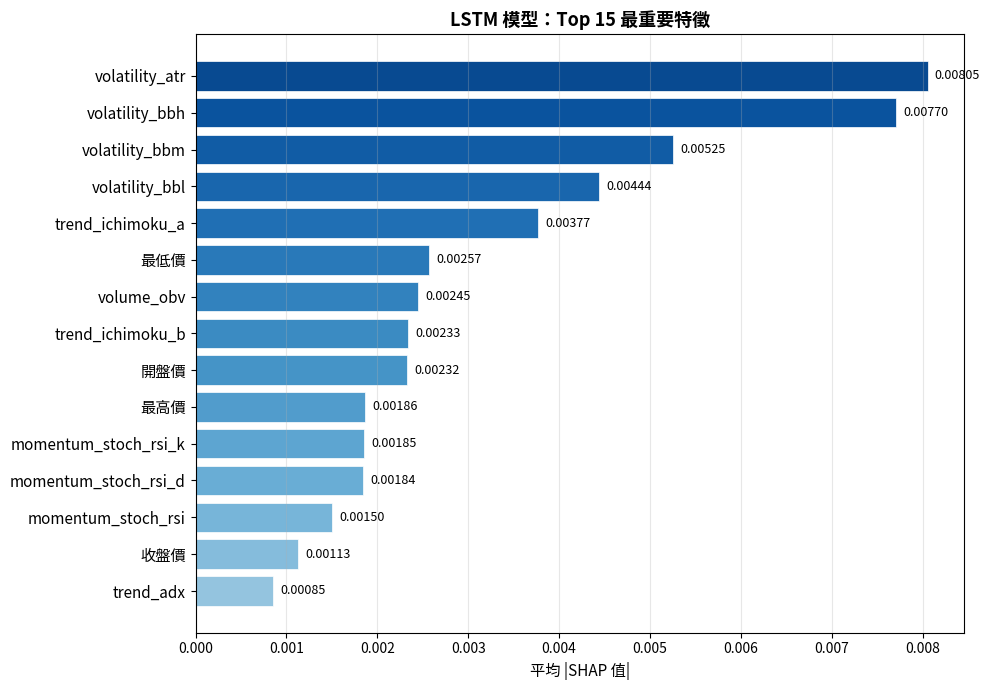


【STEP 4】繪製 SHAP Beeswarm 方向圖...


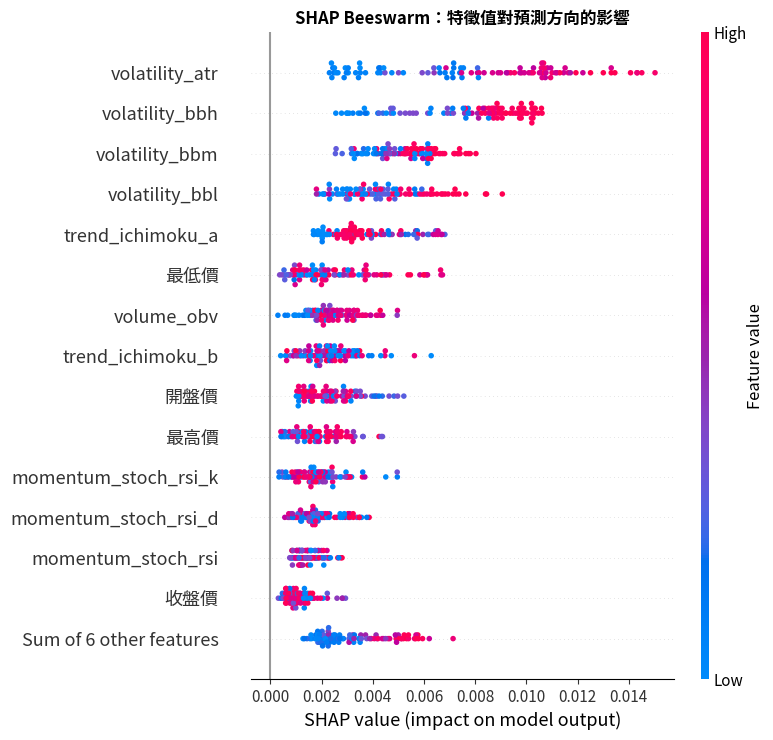


【STEP 5】繪製完整特徵排名圖...


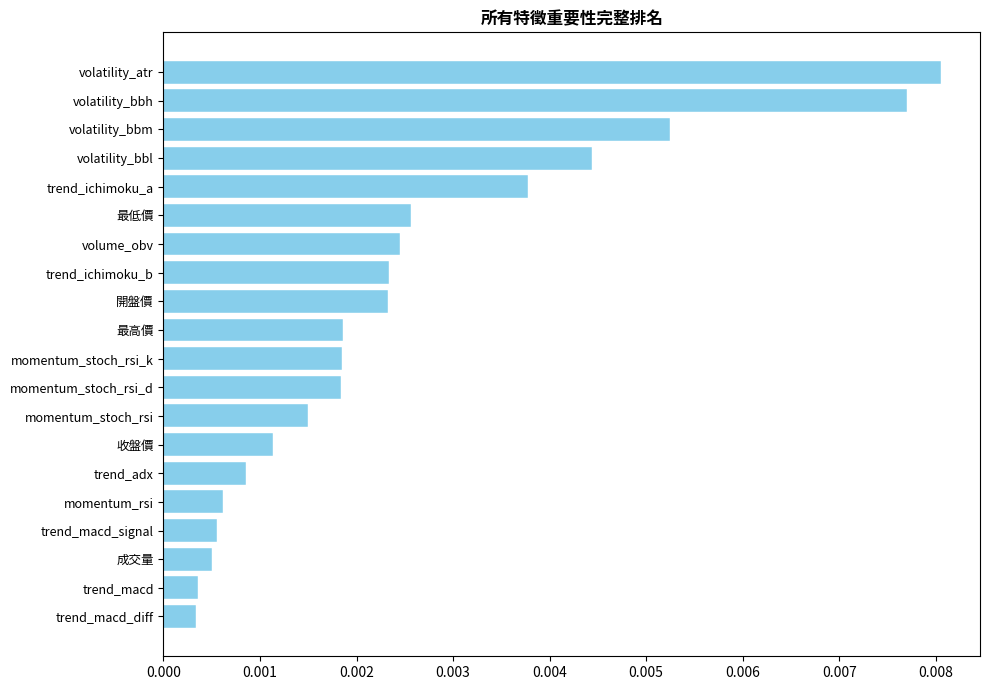


【STEP 6】儲存特徵重要性排名...
   ✅ 已儲存：shap_importance_ranking.csv


In [ ]:
import shap
from tensorflow.keras.models import load_model
import pickle

# --- 1. 設定執行參數 ---
SHAP_SAMPLE = 100  # 解釋測試集的前 100 筆資料 (增加此數值會變慢)

# --- 2. 執行完整流程 ---
try:
    # 載入模型與資料
    model, X_train_3d, X_test_3d, feature_cols = load_all()

    # 計算 SHAP 值
    shap_values, shap_2d = run_shap(model, X_train_3d, X_test_3d)

    # 繪製並儲存圖表
    mean_shap, sorted_idx, feature_array = plot_shap(shap_values, shap_2d, X_test_3d, feature_cols)

    # 儲存 CSV 排名
    save_csv(mean_shap, sorted_idx, feature_array)

except Exception as e:
    print(f"❌ 執行發生錯誤: {e}")
    print("請確認之前的路徑設定 (ZAdJUTWimiVZ) 與函式定義 (Fj61_IFim4ID) 儲存格都已正確執行過。")